## Metabolic Modelling Assignment

1. Visualize the reaction maximal activity data on the ESCHER map of the E. coli core model. For this we use the non-interactive version: 
https://escher.github.io/#/app?map=e_coli_core.Core%20metabolism&tool=Builder&scrollToZoom=true&model=e_coli_core
In order to load the data, go to “Data -> “Load reaction data” and load the file. The data will then be visualized in the same way that we inspected actual flux predictions in the interactive session in Week 2. 

a) In the interactive session, we saw reaction fluxes in a linear pathway being equal to each other due to mass balance constraints. Do you observe the same thing now for the maximal reaction activities? Explain your observations. [5 pt] 

- There are many different fluxes, this is because the pathways are not linear. In a branch where $v_1 = v_2 + v_3$ there is a degree of freedom for the individual values of $v_2$ and $v_3$


b) Some reactions are shown with grey arrows, predominantly at the lower end of the map. These can show one of two different values – identify what these values are and how their meaning differs. [5 pt]

- The two values are "no data" and "0.00". A value of 0 likely means that the estimated maximal activity of that reaction was estimated to be zero. "No data" likely means that those reactions were not estimated in the first place.

---

2. We will now establish an enzyme activity-constrained metabolic model in COBRApy. Please implement the maximal reaction activity data in the E. coli core model from the practical per the below instructions. 
- For reversible reactions, set the lower and upper flux bound to -value and +value, respectively (“value” as the maximal reaction activity). 
- For irreversible reactions, only set the maximal flux bound to +value and leave the minimal flux bound at zero. 
- For reactions without data, leave their default constraints. 
- For the glucose exchange reaction (“EX_glc__D_e”; see practical), please remove the pre-existing maximal absolute flux bound and use the high absolute default bound instead. 
- For the ATPM energy maintenance reaction (see practical), leave the lower flux as-is, since it describes cellular energy requirements separate from any maximal reaction activities. 
Please print a table listing each reaction’s lower and upper flux bound after implementing the above (no formatting requirements, simple printout sufficient). [30 pt]

In [87]:
# imports
import cobra
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [88]:
model = cobra.io.load_json_model("e_coli_core.json")
df = pd.read_csv("KEN3170_Assignment_2026_e_coli_core_expression.csv")
print(df.columns)

Index(['# Reaction ID', ' reaction activity [mmol/gDW/h] '], dtype='object')


In [89]:
# iterate through the rows
for index, row in df.iterrows():
    reaction_id = row['# Reaction ID']
    reaction_activity = row[' reaction activity [mmol/gDW/h] ']

    # skip if no data
    if reaction_id not in model.reactions:
        print("ERROR, NOT IN MODEL")
        continue

    model_reaction = model.reactions.get_by_id(reaction_id)

    #print("Changing bounds for " + str(reaction_id) + " to " + str(reaction_activity))

    # set the upper bound
    model_reaction.upper_bound = reaction_activity

    # set lower bound
    # if the lower bound is alreay less than 0 then its reversable.
    if model_reaction.lower_bound < 0.0:

        if reaction_id == "ATPM":
            #print("Skipping the lower bound change for ATPM")
            continue

        #print("     This reaction is reversable, also changing the lower bound")
        model_reaction.lower_bound = -reaction_activity
    else:
        model_reaction.lower_bound = 0.0

# I think this is what they mean by changing the maximal absolute flux bound to the high absolute default bound.
# Original lb=-10, ub=1000
# done outside the loop becuase EX_glc__D_e is not in the csv.
model.reactions.EX_glc__D_e.lower_bound = -1000.0
model.reactions.EX_glc__D_e.upper_bound = 1000.0

In [90]:
# print the new bounds
for r in model.reactions:
    print(r.id + ": lb=" + str(r.lower_bound) + ", ub=" + str(r.upper_bound))

PFK: lb=0.0, ub=13.1
PFL: lb=0.0, ub=0.0
PGI: lb=-11.1, ub=11.1
PGK: lb=-24.0, ub=24.0
PGL: lb=0.0, ub=7.3
ACALD: lb=-0.0, ub=0.0
AKGt2r: lb=-0.0, ub=0.0
PGM: lb=-21.7, ub=21.7
PIt2r: lb=-5.2, ub=5.2
ALCD2x: lb=-0.0, ub=0.0
ACALDt: lb=-1000.0, ub=1000.0
ACKr: lb=-2.5, ub=2.5
PPC: lb=0.0, ub=3.6
ACONTa: lb=-21.4, ub=21.4
ACONTb: lb=-21.4, ub=21.4
ATPM: lb=8.39, ub=1000.0
PPCK: lb=0.0, ub=13.3
ACt2r: lb=-3.6, ub=3.6
PPS: lb=0.0, ub=3.1
ADK1: lb=-27.4, ub=27.4
AKGDH: lb=0.0, ub=26.7
ATPS4r: lb=-80.1, ub=80.1
PTAr: lb=-4.47, ub=4.47
PYK: lb=0.0, ub=28.2
BIOMASS_Ecoli_core_w_GAM: lb=0.0, ub=1000.0
PYRt2: lb=-0.0, ub=0.0
CO2t: lb=-1000.0, ub=1000.0
RPE: lb=-6.3, ub=6.3
CS: lb=0.0, ub=21.4
RPI: lb=-5.6, ub=5.6
SUCCt2_2: lb=0.0, ub=0.0
CYTBD: lb=0.0, ub=41.1
D_LACt2: lb=-0.0, ub=0.0
ENO: lb=-29.3, ub=29.3
SUCCt3: lb=0.0, ub=0.0
ETOHt2r: lb=-1000.0, ub=1000.0
SUCDi: lb=0.0, ub=27.3
SUCOAS: lb=-19.4, ub=19.4
TALA: lb=-4.5, ub=4.5
THD2: lb=0.0, ub=6.5
TKT1: lb=-3.5, ub=3.5
TKT2: lb=-3.5, ub=3.5
T

---
#### 3. 
a) Carry out an Flux Balance Analysis (FBA) optimization of biomass production and report the maximal biomass production rate in the presence of the implemented constraints. [5 pt] 

In [91]:
model.reactions.EX_glc__D_e.lower_bound = -1000.0
model.reactions.EX_glc__D_e.upper_bound = 1000.0

model.objective = "BIOMASS_Ecoli_core_w_GAM"

solution = model.optimize()
print("Objective value = " + str(solution.objective_value))

Objective value = 0.8732862458582367


b) Re-establish an absolute flux bound on the glucose exchange reaction of 5 mmol/gDW/h. Explain what this constraint would describe in contrast to the expression-based constraints implemented in the rest of the model. [5 pt] 



- The constraint is imposed manually and is not derived from the estimated maximal activity. It is now modelling the system with a limited glucose input/output rate, possibly due to a deficiency. 

c) Carry out the same FBA biomass optimization as in a) under the additional constraint from b). Explain any differences you observe in the predicted maximal biomass production rate. [5 pt] 

In [92]:
model.reactions.EX_glc__D_e.lower_bound = -5.0
model.reactions.EX_glc__D_e.upper_bound = 5.0

solution = model.optimize()
print("Objective value = " + str(solution.objective_value))

Objective value = 0.41559777509290663


- The predicted maximal biomass production rate fell from 0.87 to 0.42. This means that limitting the glucose input/output rate to 5 mmol/gDW/h halved the biomass production rate by more than half.

---
#### 4. 
a) Prepare a plot of the maximal biomass production rate as a function of glucose exchange reaction flux bound in the interval [1,15] mmol/gDW/h (in uptake direction), in increments of 0.1 mmol/gDW/h. [10 pt] 

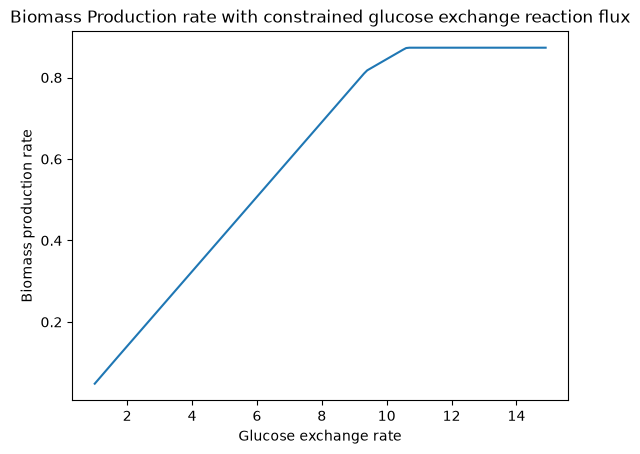

In [93]:
glc_ex_rates = np.arange(1, 15, 0.1)
biomass_rates = []

for rate in glc_ex_rates:
    model.reactions.EX_glc__D_e.lower_bound = -rate
    model.reactions.EX_glc__D_e.upper_bound = rate

    solution = model.optimize()
    biomass_rates.append(solution.objective_value)

np.array(biomass_rates)

plt.plot(glc_ex_rates, biomass_rates)
plt.title("Biomass Production rate with constrained glucose exchange reaction flux")
plt.xlabel("Glucose exchange rate")
plt.ylabel("Biomass production rate")
plt.show()

b) Does the growth rate increase indefinitely with increasing glucose exchange reaction flux bound? Please explain your observations. [15 pt] 

- The growth rate does not increase indefinetly, this shows that there are other limiting factors to biomass production other than glucose exchange rate.

c) The curve displays three segments. Identify which process gets active in the second segment, by inspecting fluxes of the exchange reactions. It is sufficient to state the ID of the relevant reaction. Hint: You can inspect the online model to identify how exchange reactions are labeled. [15 pt] 

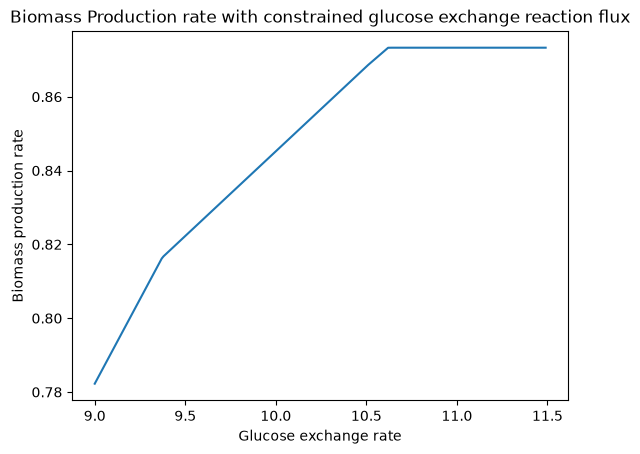

In [94]:
# first get a more zoomed in view of the three segments
glc_ex_rates = np.arange(9, 11.5, 0.01)
biomass_rates = []

for rate in glc_ex_rates:
    model.reactions.EX_glc__D_e.lower_bound = -rate
    model.reactions.EX_glc__D_e.upper_bound = rate

    solution = model.optimize()
    biomass_rates.append(solution.objective_value)

np.array(biomass_rates)

plt.plot(glc_ex_rates, biomass_rates)
plt.title("Biomass Production rate with constrained glucose exchange reaction flux")
plt.xlabel("Glucose exchange rate")
plt.ylabel("Biomass production rate")
plt.show()

- The sections appear around glc_ex_rate = 9.4 and 10.5.
- In the online model it appears that exchange reactions are labled with an `EX` prefix

In [98]:
# print the fluxes for all exchange reactions when solving the model with the given gluxose exchange rate
def print_exchange_reactions(glc_ex_rate):
    model.reactions.EX_glc__D_e.lower_bound = -glc_ex_rate
    model.reactions.EX_glc__D_e.upper_bound = glc_ex_rate
    solution = model.optimize()

    for reaction in model.reactions:
        if "EX_" in reaction.id:
            print(reaction.id + ": flux = " + str(reaction.flux))

In [100]:
print_exchange_reactions(9)

EX_ac_e: flux = 0.0
EX_acald_e: flux = 0.0
EX_akg_e: flux = 0.0
EX_co2_e: flux = 20.71067242457075
EX_etoh_e: flux = 0.0
EX_for_e: flux = 0.0
EX_fru_e: flux = 0.0
EX_fum_e: flux = 0.0
EX_glc__D_e: flux = -9.0
EX_gln__L_e: flux = 0.0
EX_glu__L_e: flux = 0.0
EX_h_e: flux = 15.692070617502182
EX_h2o_e: flux = 26.408943571436755
EX_lac__D_e: flux = 0.0
EX_mal__L_e: flux = 0.0
EX_nh4_e: flux = -4.2654896641632885
EX_o2_e: flux = -19.8063053836488
EX_pi_e: flux = -2.877687945194649
EX_pyr_e: flux = 0.0
EX_succ_e: flux = 0.0


In [101]:
print_exchange_reactions(10)

EX_ac_e: flux = 1.2516244000381753
EX_acald_e: flux = 0.0
EX_akg_e: flux = 0.0
EX_co2_e: flux = 21.527180864169516
EX_etoh_e: flux = 0.0
EX_for_e: flux = 0.0
EX_fru_e: flux = 0.0
EX_fum_e: flux = 0.0
EX_glc__D_e: flux = -10.0
EX_gln__L_e: flux = 0.0
EX_glu__L_e: flux = 0.0
EX_h_e: flux = 18.207119716395198
EX_h2o_e: flux = 27.684240190314593
EX_lac__D_e: flux = 0.0
EX_mal__L_e: flux = 0.0
EX_nh4_e: flux = -4.608919484597771
EX_o2_e: flux = -20.549999999999997
EX_pi_e: flux = -3.1093808883491
EX_pyr_e: flux = 0.0
EX_succ_e: flux = 0.0


- Changing the glucose exchange rate from 9 to 10 mmol/gDW/h slightly changed the already activated fluxes, but activated the Acitate exchange reaction (EX_ac_e).